<a href="https://colab.research.google.com/github/laraib-anwar/pytorchColab/blob/main/pytorch_model_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

# New Section

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self, in_features=4, h1=8, h2=8, out_features=3):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

torch.manual_seed(41)
model = Model()

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)

In [2]:
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)

X = my_df.drop('variety', axis=1)
y = my_df['variety']
X = X.values
y = y.values

/tmp/ipykernel_2592/1913495296.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

Epoch: 0 and loss: 1.1318365335464478
Epoch: 10 and loss: 1.1318365335464478
Epoch: 20 and loss: 1.1318365335464478
Epoch: 30 and loss: 1.1318365335464478
Epoch: 40 and loss: 1.1318365335464478
Epoch: 50 and loss: 1.1318365335464478
Epoch: 60 and loss: 1.1318365335464478
Epoch: 70 and loss: 1.1318365335464478
Epoch: 80 and loss: 1.1318365335464478
Epoch: 90 and loss: 1.1318365335464478


Text(0.5, 0, 'Epoch')

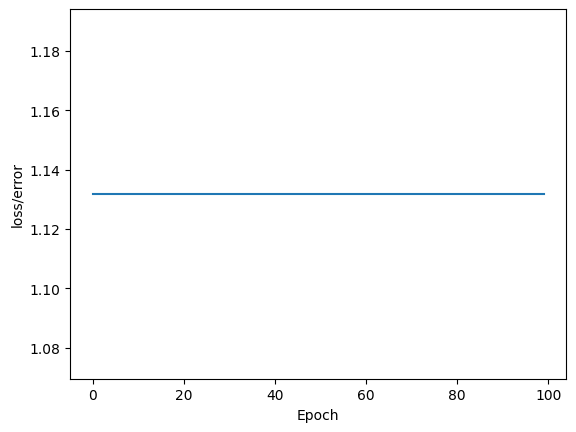

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
epochs = 100
losses = []

for i in range(epochs):
      y_pred = model.forward(X_train)
      loss = criterion(y_pred, y_train)
      losses.append(loss.detach().numpy())

      if i % 10 == 0:
          print(f'Epoch: {i} and loss: {loss}')

optimizer.zero_grad()
loss.backward()
optimizer.step()
plt.plot(range(epochs), losses)
plt.ylabel('loss/error')
plt.xlabel('Epoch')